# DQN : remplacer la Q-table par un réseau de neurones


In [1]:
import torch.nn as nn
import torch.nn.functional as F

class DQN(nn.Module):
    def __init__(self, n_observations, n_actions):
        super().__init__()
        self.layer1 = nn.Linear(n_observations, 64)
        self.layer2 = nn.Linear(64, 64)
        self.layer3 = nn.Linear(64, n_actions)
    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)


In [2]:
import random
from collections import deque, namedtuple

# Structure nommée pour organiser les expériences stockées dans le buffer
Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward'))

class ReplayMemory(object):

    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)
    
    def __len__(self):
        return len(self.memory)


## Étape 2 : Boucle d'entraînement DQN

In [3]:
import gymnasium as gym
import math
import matplotlib
import matplotlib.pyplot as plt
from itertools import count

import torch
import torch.optim as optim

env = gym.make("CartPole-v1")

is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion()

# Sélection automatique du device : GPU (cuda) > puce Apple (mps) > CPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

print(f"Device utilisé : {device}")

Device utilisé : cpu


In [4]:
BATCH_SIZE = 128 # Nombre d'expériences tirées du buffer à chaque mise à jour
GAMMA = 0.99 # Facteur d'actualisation : pondère l'importance des récompenses futures
EPS_START = 0.9 # Epsilon initial : forte exploration au départ
EPS_END = 0.01 # Epsilon minimal : l'agent exploite presque toujours ce qu'il a appris
EPS_DECAY = 2500 # Vitesse de décroissance d'epsilon (en nombre de pas)
TAU = 0.005 # Taux de mise à jour douce du target network
LR = 3e-4 # Learning rate de l'optimiseur

n_actions = env.action_space.n
state, info = env.reset()
n_observations = len(state)

# policy_net : le réseau qu'on entraîne à chaque étape
policy_net = DQN(n_observations, n_actions).to(device)
# target_net : copie figée de policy_net, mise à jour lentement pour stabiliser l'apprentissage
target_net = DQN(n_observations, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
memory = ReplayMemory(10000)

steps_done = 0

### Choisir une action : explorer ou exploiter ?

À chaque pas, l'agent choisit entre tester une action au hasard (explorer) ou faire confiance à ce qu'il a appris (exploiter).

Stratégie **epsilon-greedy** : on tire un nombre entre 0 et 1, si c'est sous epsilon on explore, sinon on exploite. Epsilon décroît exponentiellement au fil des pas, donc l'agent explore beaucoup au début puis de moins en moins.

In [5]:
def select_action(state):
    global steps_done
    sample = random.random()
    # Epsilon décroît exponentiellement : exploration au début, exploitation ensuite
    eps_threshold = EPS_END + (EPS_START - EPS_END) * math.exp(-1. * steps_done / EPS_DECAY)
    steps_done += 1

    if sample > eps_threshold:
        # Exploitation : action avec la Q-value la plus haute selon policy_net
        with torch.no_grad():
            return policy_net(state).max(1).indices.view(1, 1)
    else:
        # Exploration : action aléatoire
        return torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)

### Visualiser la progression avec `plot_durations`

Affiche la durée de chaque épisode (nombre de pas avant que le mât tombe). Plus c'est long, mieux l'agent joue. La courbe brute est bruitée donc on superpose une moyenne glissante sur 100 épisodes pour voir la tendance.

In [6]:
episode_durations = []

def plot_durations(show_result=False):
    plt.figure(1)
    durations_t = torch.tensor(episode_durations, dtype=torch.float)
    if show_result:
        plt.title('Résultat final')
    else:
        plt.clf()
        plt.title('Entraînement en cours...')
    plt.xlabel('Épisode')
    plt.ylabel('Durée')
    plt.plot(durations_t.numpy())
    # Moyenne glissante sur 100 épisodes pour lisser la courbe
    if len(durations_t) >= 100:
        means = durations_t.unfold(0, 100, 1).mean(1).view(-1)
        means = torch.cat((torch.zeros(99), means))
        plt.plot(means.numpy())
    plt.pause(0.001)
    if is_ipython:
        if not show_result:
            display.display(plt.gcf())
            display.clear_output(wait=True)
        else:
            display.display(plt.gcf())

### L'apprentissage DQN avec `optimize_model`

C'est ici que le réseau apprend. On tire un batch d'expériences du buffer et on met à jour `policy_net` pour rapprocher ses prédictions des valeurs cibles.

Les valeurs cibles viennent de l'**équation de Bellman** :

> Q_cible(s, a) = r + γ · max_a' Q(s', a')

La valeur d'une action = récompense immédiate + meilleure valeur future possible, actualisée par γ.

Point important : on utilise `target_net` pour estimer Q(s', a'), pas `policy_net`. Si on utilisait `policy_net`, la cible changerait à chaque mise à jour et l'apprentissage deviendrait instable.

In [7]:
def optimize_model():
    # On attend d'avoir assez d'expériences pour remplir un batch
    if len(memory) < BATCH_SIZE:
        return

    transitions = memory.sample(BATCH_SIZE)
    # Réorganise le batch : de [[s,a,s',r], ...] à ([s,...], [a,...], [s',...], [r,...])
    batch = Transition(*zip(*transitions))

    # Masque des états non terminaux (next_state est None quand le mât est tombé)
    non_final_mask = torch.tensor(
        tuple(map(lambda s: s is not None, batch.next_state)),
        device=device, dtype=torch.bool
    )
    non_final_next_states = torch.cat([s for s in batch.next_state if s is not None])

    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    # Q-values prédites par policy_net pour les actions réellement effectuées
    state_action_values = policy_net(state_batch).gather(1, action_batch)

    # Q-values cibles calculées par target_net (sans gradient pour ne pas l'entraîner)
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1).values

    # Équation de Bellman : Q_cible = r + γ * max_a' Q(s', a')
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    # Perte de Huber : moins sensible aux valeurs aberrantes que la MSE
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    optimizer.zero_grad()
    loss.backward()
    # Clipping des gradients pour éviter les explosions pendant la rétropropagation
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()

### Boucle d'entraînement

À chaque épisode, l'agent repart de zéro et joue jusqu'à ce que le mât tombe.

À chaque pas : il choisit une action, observe le résultat, stocke l'expérience dans le buffer, puis entraîne le réseau. `target_net` est mis à jour par soft update après chaque optimisation (ses poids glissent doucement vers ceux de `policy_net`).

Entraînement terminé


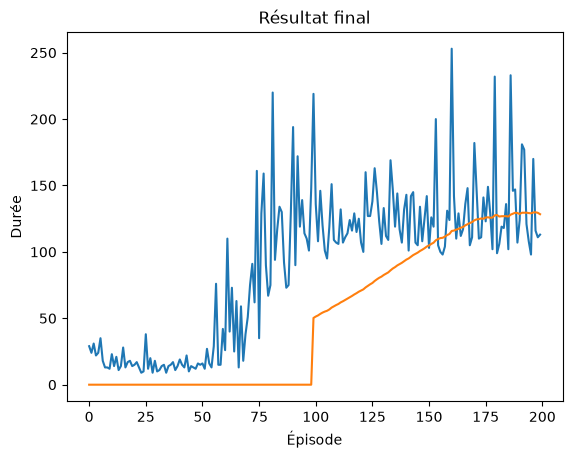

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [8]:
# 50 épisodes sur CPU (sans GPU, 600 épisodes prendrait trop longtemps)
if torch.cuda.is_available() or torch.backends.mps.is_available():
    num_episodes = 600
else:
    num_episodes = 200

for i_episode in range(num_episodes):
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

    for t in count():
        action = select_action(state)
        observation, reward, terminated, truncated, _ = env.step(action.item())
        reward = torch.tensor([reward], device=device)
        done = terminated or truncated

        # next_state est None si l'épisode est terminé
        if terminated:
            next_state = None
        else:
            next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

        memory.push(state, action, next_state, reward)
        state = next_state

        optimize_model()

        # Soft update : θ' ← τ·θ + (1-τ)·θ' — plus stable qu'une copie complète périodique
        target_net_state_dict = target_net.state_dict()
        policy_net_state_dict = policy_net.state_dict()
        for key in policy_net_state_dict:
            target_net_state_dict[key] = (
                policy_net_state_dict[key] * TAU + target_net_state_dict[key] * (1 - TAU)
            )
        target_net.load_state_dict(target_net_state_dict)

        if done:
            episode_durations.append(t + 1)
            plot_durations()
            break

print('Entraînement terminé')
plot_durations(show_result=True)
plt.ioff()
plt.show()

**Observations :**

Deux phases dans l'entraînement :

- **Épisodes 0-90 environ** : durées faibles, entre 10 et 30 pas. Epsilon est encore élevé, l'agent explore beaucoup et le buffer s'accumule sans que le réseau ait assez de signal pour apprendre.

- **À partir de ~90 épisodes** : décollage brutal, les durées passent à 150-250 pas. Epsilon a suffisamment baissé, le buffer est riche et les Q-values commencent à être fiables.

La moyenne glissante atteint ~140 en fin d'entraînement, ce qui confirme que l'agent a bien appris quelque chose.

## Entraînement avec Stable-Baselines3

In [9]:
from stable_baselines3 import DQN as DQN_SB3
from stable_baselines3.common.evaluation import evaluate_policy

env_sb3 = gym.make("CartPole-v1")

# MlpPolicy = réseau de neurones dense (Multi-Layer Perceptron)
model = DQN_SB3('MlpPolicy', env_sb3, verbose=1, tensorboard_log="./logs/")

model.learn(total_timesteps=100000)

# Évaluation sur 100 épisodes pour avoir une mesure fiable
mean_reward, std_reward = evaluate_policy(model, env_sb3, n_eval_episodes=100)
print(f"Récompense moyenne : {mean_reward:.2f} +/- {std_reward:.2f}")

model.save("dqn_cartpole")
print("Modèle sauvegardé : dqn_cartpole.zip")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Logging to ./logs/DQN_3
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 24.2     |
|    ep_rew_mean      | 24.2     |
|    exploration_rate | 0.991    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 4618     |
|    time_elapsed     | 0        |
|    total_timesteps  | 97       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 23       |
|    ep_rew_mean      | 23       |
|    exploration_rate | 0.983    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1859     |
|    time_elapsed     | 0        |
|    total_timesteps  | 184      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.479    |
|    n_updates        | 20       |
-------

/Users/utilisateur/Rapha/ai_engineer/rl-agent-training/.venv/lib/python3.11/site-packages/stable_baselines3/common/evaluation.py:67: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Récompense moyenne : 238.90 +/- 18.84
Modèle sauvegardé : dqn_cartpole.zip


**Observations**

SB3 atteint 211 de récompense moyenne sur 100 épisodes (écart-type 50). Le max théorique de CartPole est 500, donc à 211 l'agent s'en sort bien.

Perte finale à 0.13 et exploration figée à 0.05 : le réseau a convergé. L'entraînement a duré 135 secondes à ~735 pas/seconde sur CPU.

## Conclusion

Les deux approches apprennent à jouer à CartPole, mais avec des résultats et un effort très différents.

| | DQN manuel | SB3 |
|---|---|---|
| Récompense finale | ~140 (moyenne glissante) | 211 (évaluation 100 épisodes) |
| Volume d'entraînement | 200 épisodes | 100 000 pas |
| Temps d'exécution | ~2 min | ~2min15 |
| Lignes de code | ~80 | 3 |

SB3 fait mieux principalement parce que ses hyperparamètres sont bien calibrés et que 100 000 pas c'est plus d'expérience que 200 épisodes. Avec le même volume, l'écart serait bien plus faible.

L'intérêt du DQN manuel c'est de comprendre ce que SB3 fait en interne : le replay buffer, le target network, l'équation de Bellman, la stratégie epsilon-greedy. En pratique on utilise toujours SB3 ou équivalent, mais comprendre le fonctionnement aide à diagnostiquer les problèmes et à choisir le bon algorithme.